In [136]:
import os
import shutil
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

In [146]:
def is_bad_file(filename, bad_list):
    for code in bad_list:
        if code in filename:
            return True
    return False

def copy_and_remove_bad_files(root_dir, bad_list, copy_dir):
    os.makedirs(copy_dir, exist_ok=True)

    for filename in os.listdir(root_dir):
        
        if filename.endswith(".png") and "LP-" in filename:
            if not is_bad_file(filename, bad_list):
                print(filename)
                src_path = os.path.join(root_dir, filename)
                dst_path = os.path.join(copy_dir, filename)
                shutil.copy2(src_path, dst_path)


    return copy_dir

# List of patients with t2w
bad_list = ["LP-0009","LP-0010","LP-0085","LP-0117","LP-0216","LP-0576","LP-0080","LP-0136","LP-0239","LP-0337","LP-0343","LP-0367","LP-0568","LP-0998"]

root_dir = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3Regions"
root_copy = "E:\MRgLITT Data\\new data\\2021-12-21\\segmentationData_3Regions_no_t2"
copy_and_remove_bad_files(root_dir, bad_list, root_copy)

LP-0001-01-01-01-S2CroppedSeg.png
LP-0001-01-01-02-S2CroppedSeg.png
LP-0001-01-01-03-S2CroppedSeg.png
LP-0001-01-01-04-S2CroppedSeg.png
LP-0001-01-01-05-S2CroppedSeg.png
LP-0002-01-01-01-S2CroppedSeg.png
LP-0002-01-01-02-S2CroppedSeg.png
LP-0002-01-01-03-S2CroppedSeg.png
LP-0002-01-01-04-S2CroppedSeg.png
LP-0003-01-01-02-S2CroppedSeg.png
LP-0003-01-01-03-S2CroppedSeg.png
LP-0003-01-01-04-S2CroppedSeg.png
LP-0003-01-01-05-S2CroppedSeg.png
LP-0004-01-01-01-S2CroppedSeg.png
LP-0004-01-01-02-S2CroppedSeg.png
LP-0004-01-01-03-S2CroppedSeg.png
LP-0004-01-01-04-S2CroppedSeg.png
LP-0004-01-01-06-S2CroppedSeg.png
LP-0005-01-01-01-S2CroppedSeg.png
LP-0005-01-01-03-S2CroppedSeg.png
LP-0005-01-01-04-S2CroppedSeg.png
LP-0005-01-01-05-S2CroppedSeg.png
LP-0006-02-01-02-S2CroppedSeg.png
LP-0006-02-01-03-S2CroppedSeg.png
LP-0007-01-01-01-S2CroppedSeg.png
LP-0007-01-01-02-S2CroppedSeg.png
LP-0007-01-01-03-S2CroppedSeg.png
LP-0008-01-01-01-S2CroppedSeg.png
LP-0008-01-01-02-S2CroppedSeg.png
LP-0011-01-01-

'E:\\MRgLITT Data\\new data\\2021-12-21\\segmentationData_3Regions_no_t2'

In [154]:
root_dir = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_2Regions_no_t2"
root_copy = "E:\MRgLITT Data\\new data\\2021-12-21\\segmentationData_3Regions_no_t2"

two_reg = os.listdir(root_dir)
three_reg = os.listdir(root_copy)

for file in three_reg:
    # print(file)
    three_path = os.path.join(root_copy,file)
    print(three_path)

    if file not in two_reg:
        os.remove(three_path)

E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0001-01-01-01-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0001-01-01-02-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0001-01-01-03-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0001-01-01-04-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0001-01-01-05-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0002-01-01-01-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0002-01-01-02-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0002-01-01-03-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0002-01-01-04-S2CroppedSeg.png
E:\MRgLITT Data\new data\2021-12-21\segmentationData_3Regions_no_t2\LP-0003-01-01-

In [157]:
def convert_to_3channel(seg_dir):

    # Convert seg png to np array
    seg = Image.open(seg_dir)
    seg_np = np.array(seg)

    # Stack np array to create 51x51x3
    seg3d = np.stack([seg_np] * 3, axis=-1)
    
    # Return as PIL Image
    return(Image.fromarray(seg3d))

#####################################

root_dir_1d = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3Regions_no_t2"
final_dir__3d = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3Regions_no_t2_3D"

for filename in os.listdir(root_dir_1d):
    if filename.lower().endswith(".png"):
        file_path = os.path.join(root_dir_1d, filename)
        # print("Current png:", file_path)
        
        # Convert 51x51x1 to 51x51x3
        seg_png = convert_to_3channel(file_path)
        output_path = os.path.join(final_dir__3d, filename)

        # Save image
        seg_png.save(output_path)

In [158]:
def convert_to_mixedChannel(seg_dir, anatomical_dir):

    # Convert seg png to np array
    seg = Image.open(seg_dir)
    seg_np = np.array(seg)

    # Convert seg png to np array
    anatomical = Image.open(anatomical_dir)
    anat_np = np.array(anatomical)

    # Replace the second channel of anat_np with seg_np
    mixed_np = anat_np
    mixed_np[:, :, 1] = seg_np

    return(Image.fromarray(mixed_np).convert("L"))

    # print(mixed_np.shape)



seg_1d = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3Regions_no_t2"
anatomical_dir = "E:\MRgLITT Data\\new data\\2021-12-21\\anatomicalProbesEye_Corrected"
new_dir ="E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3Regions_no_t2_1D"


filenames1 = os.listdir(seg_1d)
filenames2 = os.listdir(anatomical_dir)
combined_filenames = zip(filenames1, filenames2)

# Now you can iterate through both folders simultaneously
for filename_seg, filename_anat in combined_filenames:
    file_path_seg = os.path.join(seg_1d, filename_seg)
    file_path_anat = os.path.join(anatomical_dir, filename_anat)

    # print(file_path_anat)
        
    # Convert 51x51x1 to 51x51x3
    mixed_png = convert_to_mixedChannel(file_path_seg, file_path_anat)
    output_path = os.path.join(new_dir, filename_anat)

    # print(output_path)

    # Save image
    mixed_png.save(output_path)


array([  0, 127, 255], dtype=uint8)

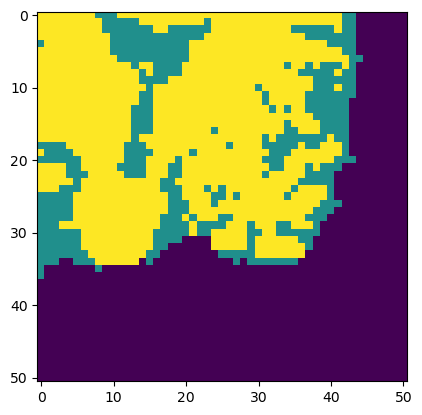

In [134]:
# dir = Image.open("E:\MRgLITT Data\\new data\\2021-12-21\\anatomical_seg_mix\LP-0001-01-01-01-S2Cropped.png")
dir = Image.open("E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_allData\LP-0001-01-01-01-S2CroppedSeg.png")
nump = np.array(dir)
plt.imshow(nump)

np.unique(nump)

array([ 13,  14,  16,  18,  19,  21,  22,  24,  26,  27,  29,  30,  32,
        33,  35,  37,  38,  40,  41,  43,  45,  46,  48,  49,  51,  53,
        54,  56,  57,  59,  61,  62,  64,  65,  67,  69,  70,  72,  73,
        75,  76,  78,  80,  81,  83,  84,  86,  88,  89,  91,  92,  94,
        96,  97,  99, 100, 102, 104, 105, 107, 108, 110, 112, 113, 115,
       116, 118, 120, 121, 123, 124, 126, 128, 129, 131, 132, 134, 135,
       137, 139, 140, 142, 143, 145, 147, 148, 150, 151, 153, 155, 156,
       158, 159, 161, 163, 164, 166, 167, 169, 171, 172, 174, 175, 177,
       178, 180, 182, 183, 185, 186, 188, 190, 191, 193, 194, 196, 198,
       199, 201, 202, 204, 206, 207, 209, 210, 212, 214, 215, 217, 218,
       220, 222, 223, 225, 226, 228, 230, 231, 233, 234, 236, 237, 239,
       241, 242, 244, 245, 247, 249, 250, 252, 253, 255], dtype=uint8)

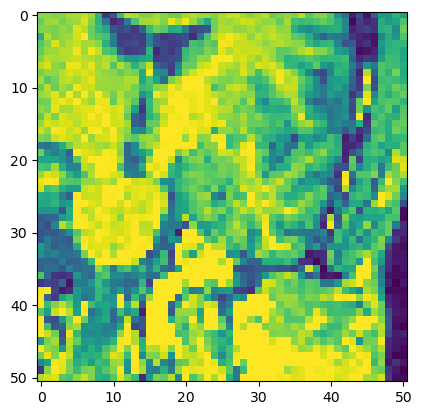

In [135]:
dir2 = Image.open("E:\MRgLITT Data\\new data\\2021-12-21\\anatomicalProbesEye\LP-0001-01-01-01-S2Cropped.png")
nump = np.array(dir2)[:,:,1]
plt.imshow(nump)

np.unique(nump)

In [64]:
# import os

# def get_common_filenames(folder1, folder2):
#     # Get all filenames from both folders
#     filenames1 = set(os.listdir(folder1))
#     filenames2 = set(os.listdir(folder2))

#     # Find the common filenames based on the shared part of the file names
#     # common_filenames = [filename2 for filename2 in filenames2 if any(filename1[:16] == filename2[:16] for filename1 in filenames1)]
#     common_filenames = [filename1 for filename1 in filenames1 if any(filename2[:16] == filename1[:16] for filename2 in filenames2)]

#     # print(len(common_filenames))
#     # print(common_filenames)

#     return common_filenames

# def remove_unmatched_files(folder, common_filenames):
#     # Get all filenames in the folder
#     all_filenames = os.listdir(folder)

#     # Remove files that are not present in the common_filenames list and whose first 15 characters match
#     for filename in all_filenames:
#         if filename not in common_filenames:
#             # print(filename)
#             os.remove(os.path.join(folder,filename))

# if __name__ == "__main__":
#     temp_dir = r"E:\\MRgLITT Data\\new data\\2021-12-21\\temperatureData_Corrected"
#     seg_dir = r"E:\\MRgLITT Data\\new data\\2021-12-21\segmentationData_Corrected"

#     common_filenames = get_common_filenames(seg_dir, temp_dir)
#     print(common_filenames)
#     print(len(common_filenames))

#     # Remove unmatched files from both folders
#     remove_unmatched_files(seg_dir, common_filenames)


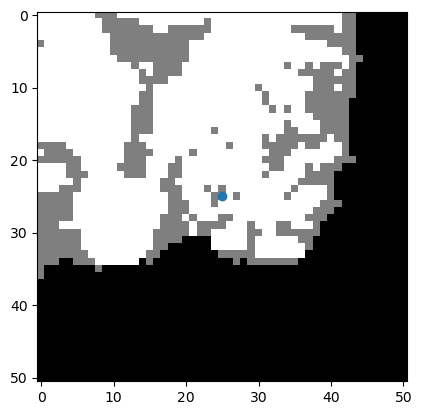

In [11]:
# test_seg = Image.open("E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_3D\LP-0001-01-01-01-S2CroppedSeg.png")
# test_seg_np = np.array(test_seg)
# test_seg_np.shape

# plt.imshow(test_seg_np)
# plt.scatter(25,25)

In [35]:
import os

def find_duplicate_filenames(folder_path):
    # Create a dictionary to store filenames and their occurrences
    filename_dict = {}
    duplicate_files = []

    # Iterate over the files in the folder
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(".png"):
            # If the file is a PNG file, check if its name is already in the dictionary
            if filename in filename_dict:
                # If the filename is already present, add it to the duplicate_files list
                duplicate_files.append(filename)
            else:
                # If the filename is not present, add it to the dictionary with a count of 1
                filename_dict[filename] = 1

    return duplicate_files

if __name__ == "__main__":
    file_path = "E:\MRgLITT Data\\new data\\2021-12-21\segmentationData_allData"
    duplicate_files = find_duplicate_filenames(file_path)

    if duplicate_files:
        print("Duplicate files found:")
        for filename in duplicate_files:
            print(filename)
    else:
        print("No duplicate files found.")



No duplicate files found.
